Shape of the dataset: (121, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:
    sepal_length  sepal_width petal_length petal_width    species
0         120.0          4.0       setosa  versicolor  virginica
1           6.4          2.8          5.6         2.2          2
2           5.0          2.3          3.3         1.0          1
3           4.9          2.5          4.5         1.7          2
4           4.9          3.1          1.5         0.1          0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  121 non-null    float64
 1   sepal_width   121 non-null    float64
 2   petal_length  121 non-null    object 
 3   petal_width   121 non-null    object 
 4   species       121 non-null    object 
dtypes: float64(2), object(3)
memory usage: 4.9+ KB
No

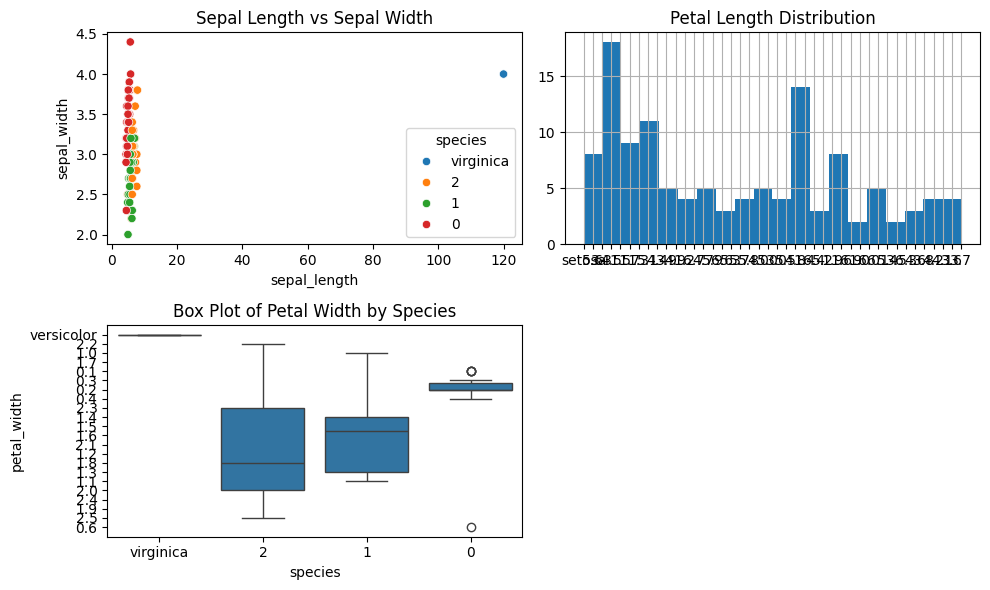

Task 1 completed! We explored the Iris dataset and made some plots.


In [1]:
# Task 1: Exploring and Visualizing a Simple Dataset (Iris)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Iris dataset directly from online link (no need to upload file)
url = "https://storage.googleapis.com/download.tensorflow.org/data/iris_training.csv"
df = pd.read_csv(url, header=None)  # this file has no header

# Give proper column names
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

print("Shape of the dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# Visualizations
plt.figure(figsize=(10, 6))

# Scatter plot to see relationship between features
plt.subplot(2, 2, 1)
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)
plt.title('Sepal Length vs Sepal Width')

# Histograms to see distributions
plt.subplot(2, 2, 2)
df['petal_length'].hist(bins=20)
plt.title('Petal Length Distribution')

# Box plots to check outliers
plt.subplot(2, 2, 3)
sns.boxplot(x='species', y='petal_width', data=df)
plt.title('Box Plot of Petal Width by Species')

plt.tight_layout()
plt.show()

print("Task 1 completed! We explored the Iris dataset and made some plots.")

/tmp/ipykernel_4078/3184796403.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download('AAPL', start='2020-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed


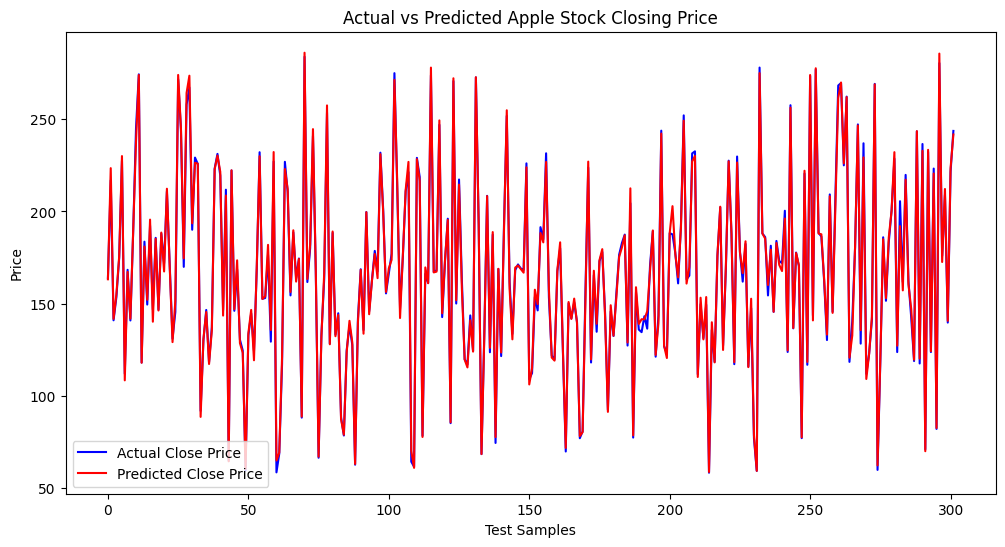

Model trained! Linear Regression used for short-term stock prediction.
You can try other stocks like 'TSLA' by changing the ticker.


In [2]:
# Task 2: Predict Next Day's Closing Price using Linear Regression

!pip install yfinance -q   # install yfinance (only needed once)

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Download Apple stock data
stock = yf.download('AAPL', start='2020-01-01', end='2025-12-31')

# Create features and target (predict next day's Close)
data = stock[['Open', 'High', 'Low', 'Volume', 'Close']].copy()

# Shift Close price to create target (next day close)
data['Target'] = data['Close'].shift(-1)

# Drop the last row because it has no target
data = data.dropna()

# Features and target
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Target']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Close Price', color='blue')
plt.plot(predictions, label='Predicted Close Price', color='red')
plt.title('Actual vs Predicted Apple Stock Closing Price')
plt.xlabel('Test Samples')
plt.ylabel('Price')
plt.legend()
plt.show()

print("Model trained! Linear Regression used for short-term stock prediction.")
print("You can try other stocks like 'TSLA' by changing the ticker.")

Dataset shape: (20640, 9)

First 5 rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Mean Absolute Error (MAE): 0.53
Root Mean Squared Error (RMSE): 0.75


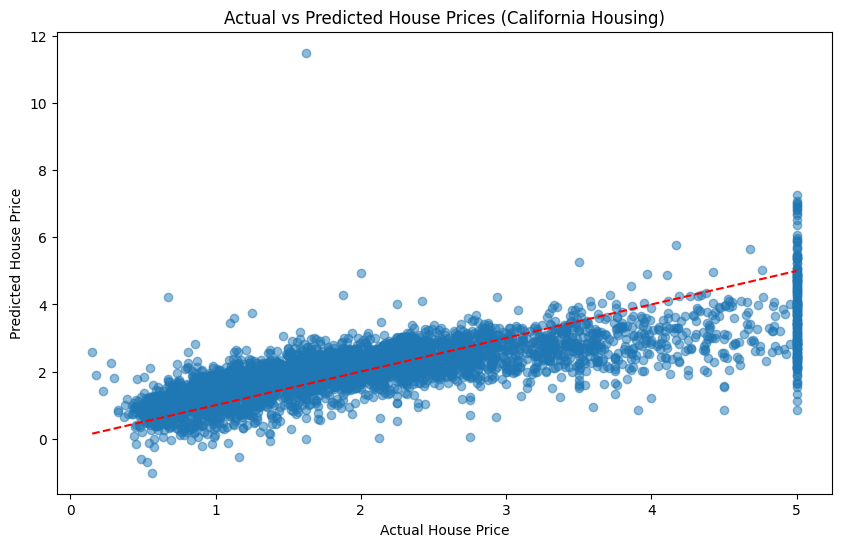

Task 6 completed! We predicted house prices using basic features from the California Housing dataset.


In [4]:
# Task 6: House Price Prediction using Linear Regression

import pandas as pd
from sklearn.datasets import fetch_california_housing # Use California housing dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Load California housing dataset
california_housing = fetch_california_housing(as_frame=True) # Load as DataFrame for convenience
df = california_housing.frame  # Access the DataFrame directly
df.rename(columns={'MedHouseVal': 'PRICE'}, inplace=True) # Rename target column for consistency with original code

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# Simple preprocessing (no missing values in this dataset, but check anyway)
# X = df.drop('PRICE', axis=1) # No need to drop, as target is already 'PRICE'
X = df.drop(columns=['PRICE'])
y = df['PRICE']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted House Prices (California Housing)')
plt.show()

print("Task 6 completed! We predicted house prices using basic features from the California Housing dataset.")